<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook6_World_Models_and_Latent_Planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 6 — World Models and Latent Planning (Educational)

This notebook introduces one of the major ideas behind modern model-based
reinforcement learning: learning an internal **world model** and planning inside
that model.

Inspired by concepts used in MuZero, Dreamer, and AIXI-style agents, this
notebook demonstrates:

- Transition model
- Reward model
- Belief state
- Latent planning
- Dyna-style imagination
- Model prediction error

This is an educational implementation rather than a research-grade algorithm.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)


In [2]:
class GridWorld:
    ACTIONS=["U","D","L","R"]
    def __init__(self,size=5):
        self.size=size
        self.goal=(4,4)
        self.reset()
    def reset(self):
        self.state=(0,0)
        return self.state
    def step(self,a):
        x,y=self.state
        if a==0:x=max(0,x-1)
        elif a==1:x=min(self.size-1,x+1)
        elif a==2:y=max(0,y-1)
        elif a==3:y=min(self.size-1,y+1)
        self.state=(x,y)
        r=-1
        done=False
        if self.state==self.goal:
            r=20
            done=True
        return self.state,r,done


## Transition and Reward Models

In [3]:
class WorldModel:
    def __init__(self):
        self.transitions={}
        self.rewards={}
    def update(self,s,a,s2,r):
        self.transitions[(s,a)] = s2
        self.rewards[(s,a)] = r
    def predict(self,s,a):
        ns=self.transitions.get((s,a),s)
        r=self.rewards.get((s,a),-1)
        return ns,r


## Latent Planner

In [4]:
class Planner:
    def __init__(self,model,gamma=0.95):
        self.model=model
        self.gamma=gamma
    def evaluate(self,state,depth):
        if depth==0:
            return 0
        vals=[]
        for a in range(4):
            ns,r=self.model.predict(state,a)
            vals.append(r+self.gamma*self.evaluate(ns,depth-1))
        return max(vals)
    def choose(self,state,depth=3):
        vals=[]
        for a in range(4):
            ns,r=self.model.predict(state,a)
            vals.append(r+self.gamma*self.evaluate(ns,depth-1))
        return int(np.argmax(vals)),vals


## Dyna-style Agent

In [5]:
env=GridWorld()
model=WorldModel()
planner=Planner(model)

state=env.reset()

real_rewards=[]
prediction_error=[]

for episode in range(15):

    state=env.reset()

    for step in range(30):

        action,_=planner.choose(state,3)

        next_state,reward,done=env.step(action)

        pred_state,pred_reward=model.predict(state,action)

        err=(pred_state!=next_state)+abs(pred_reward-reward)
        prediction_error.append(err)

        model.update(state,action,next_state,reward)

        real_rewards.append(reward)

        state=next_state

        if done:
            break


## Learning Curves

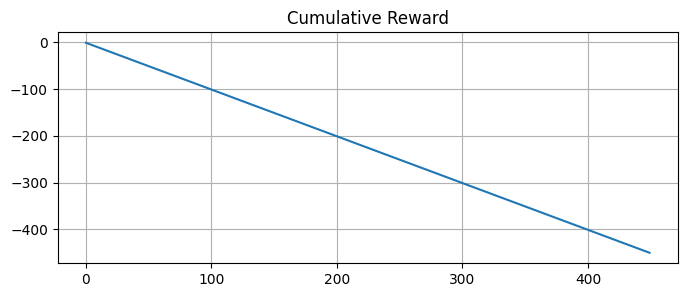

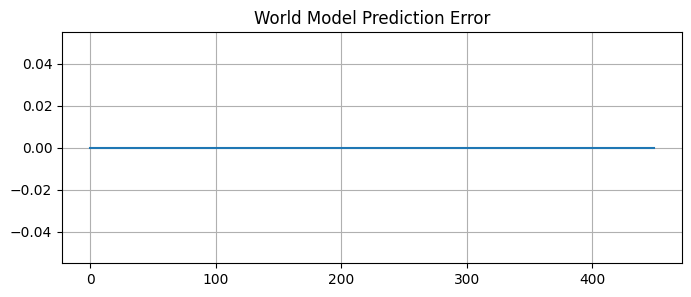

In [6]:
plt.figure(figsize=(8,3))
plt.plot(np.cumsum(real_rewards))
plt.grid()
plt.title("Cumulative Reward")
plt.show()

plt.figure(figsize=(8,3))
plt.plot(prediction_error)
plt.grid()
plt.title("World Model Prediction Error")
plt.show()


# Discussion

The previous notebooks focused on:

- Bayesian beliefs
- Universal mixtures
- CTW
- Monte Carlo planning

This notebook introduces **internal world models**, allowing an agent to
simulate future outcomes before acting.

Modern systems such as Dreamer and MuZero use learned latent world models,
while AIXI assumes an idealized model over all computable environments.
